# Smart Job Market Analyzer
## End-to-end Data Science Project

**Dataset:** 1,610,462 job postings  
**Goal:** Predict salary brackets and identify skill demand trends  
**Stack:** Python, Pandas, SQLite, Scikit-learn, Matplotlib, Seaborn, Streamlit  
**Live App:** https://job-market-analyzer-ehhurd69zcrfjsveynwuxh.streamlit.app  
**GitHub:** https://github.com/3Paradox/job-market-analyzer  

### Project Phases
- Phase 1 — Data Collection & Cleaning
- Phase 2 — SQL Database & ETL
- Phase 3 — EDA & Visualization  
- Phase 4 — ML Model (3 algorithms compared)
- Phase 5 — Streamlit Dashboard (deployed)

## Phase 1 — Data Collection & Cleaning
Loading the job descriptions dataset, exploring its structure, cleaning missing values and duplicates, and saving a clean version for analysis.

In [95]:
import pandas as pd

In [2]:
df = pd.read_csv("job_descriptions.csv")

In [3]:
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [60]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1610462, 26)


In [61]:
print(df.columns.tolist())

['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile', 'exp_min', 'exp_category', 'salary_avg']


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610462 entries, 0 to 1610461
Data columns (total 26 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Job Id            1610462 non-null  int64  
 1   Experience        1610462 non-null  object 
 2   Qualifications    1610462 non-null  object 
 3   Salary Range      1610462 non-null  object 
 4   location          1610462 non-null  object 
 5   Country           1610462 non-null  object 
 6   latitude          1610462 non-null  float64
 7   longitude         1610462 non-null  float64
 8   Work Type         1610462 non-null  object 
 9   Company Size      1610462 non-null  int64  
 10  Job Posting Date  1610462 non-null  object 
 11  Preference        1610462 non-null  object 
 12  Contact Person    1610462 non-null  object 
 13  Contact           1610462 non-null  object 
 14  Job Title         1610462 non-null  object 
 15  Role              1610462 non-null  object 
 16  

In [4]:
df.isnull().sum()

Job Id                 0
Experience             0
Qualifications         0
Salary Range           0
location               0
Country                0
latitude               0
longitude              0
Work Type              0
Company Size           0
Job Posting Date       0
Preference             0
Contact Person         0
Contact                0
Job Title              0
Role                   0
Job Portal             0
Job Description        0
Benefits               0
skills                 0
Responsibilities       0
Company                0
Company Profile     5478
dtype: int64

In [5]:
# Most common job titles
print(df["Job Title"].value_counts().head(10))

Job Title
UX/UI Designer                  48551
Digital Marketing Specialist    27975
Software Engineer               27630
Network Engineer                24393
Software Tester                 20945
Executive Assistant             20776
Procurement Manager             20734
Financial Advisor               20687
Sales Representative            17664
Social Media Manager            17613
Name: count, dtype: int64


In [6]:
df.describe()

,Job Id,latitude,longitude,Company Size
count,1.615940e+06,1.615940e+06,1.615940e+06,1.615940e+06
mean,1.548935e+15,1.937743e+01,1.639926e+01,7.370467e+04
std,8.946722e+14,2.355690e+01,7.066762e+01,3.529886e+04
min,1.817948e+11,-4.090060e+01,-1.751982e+02,1.264600e+04
25%,7.740508e+14,5.152100e+00,-1.531010e+01,4.311400e+04
50%,1.547858e+15,1.807080e+01,1.914510e+01,7.363300e+04
75%,2.323729e+15,3.907420e+01,4.757690e+01,1.043000e+05
max,3.099618e+15,7.170690e+01,1.780650e+02,1.348340e+05


In [7]:
print("Before:", len(df))
df = df.drop_duplicates()
print("After removing duplicates:", len(df))

Before: 1615940
After removing duplicates: 1615940


In [8]:
# See which columns have missing data
print(df.isnull().sum())

# Drop rows where the most important columns are empty
df = df.dropna(subset=["Company Profile"])

print("After dropping nulls:", len(df))

Job Id                 0
Experience             0
Qualifications         0
Salary Range           0
location               0
Country                0
latitude               0
longitude              0
Work Type              0
Company Size           0
Job Posting Date       0
Preference             0
Contact Person         0
Contact                0
Job Title              0
Role                   0
Job Portal             0
Job Description        0
Benefits               0
skills                 0
Responsibilities       0
Company                0
Company Profile     5478
dtype: int64
After dropping nulls: 1610462


In [9]:
# Clean key text columns on the full data
df["Job Title"] = df["Job Title"].str.strip().str.lower()
df["skills"]    = df["skills"].str.strip().str.lower()
df["location"]  = df["location"].str.strip()
df["Company"]   = df["Company"].str.strip()

print("Full clean dataset:", df.shape)
df.head()

Full clean dataset: (1610462, 23)


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,digital marketing specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","social media platforms (e.g., facebook, twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,web developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","html, css, javascript frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,operations manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",quality control processes and methodologies st...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,network engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",wireless network design and architecture wi-fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,event manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",event planning conference logistics budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [10]:
df = df.reset_index(drop=True)
print("Final shape:", df.shape)
df.head()

Final shape: (1610462, 23)


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,digital marketing specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","social media platforms (e.g., facebook, twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,web developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","html, css, javascript frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,operations manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",quality control processes and methodologies st...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,network engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",wireless network design and architecture wi-fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,event manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",event planning conference logistics budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [11]:
df.to_csv("jobs_clean.csv", index=False)
print("Saved successfully!")

Saved successfully!


In [12]:
# Reload and check
df_check = pd.read_csv("jobs_clean.csv")
print("Reloaded rows:", len(df_check))
df_check.head()

Reloaded rows: 1610462


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,digital marketing specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","social media platforms (e.g., facebook, twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,web developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","html, css, javascript frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,operations manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",quality control processes and methodologies st...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,network engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",wireless network design and architecture wi-fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,event manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",event planning conference logistics budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


## Phase 2 — SQL Database & ETL Pipeline
Loading cleaned data into SQLite and writing SQL queries for insights.

In [13]:
import pandas as pd
import sqlite3

In [14]:
df = pd.read_csv("jobs_clean.csv")
print("Loaded rows:", len(df))
df.head()

Loaded rows: 1610462


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,digital marketing specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","social media platforms (e.g., facebook, twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,web developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","html, css, javascript frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,operations manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",quality control processes and methodologies st...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,network engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",wireless network design and architecture wi-fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,event manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",event planning conference logistics budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [15]:
# Connect to database (creates the file if it doesn't exist)
conn = sqlite3.connect("jobs.db")

# Load the entire dataframe into a SQL table called "jobs"
df.to_sql("jobs", conn, if_exists="replace", index=False)

print("Database created successfully!")
print("Table 'jobs' loaded with", len(df), "rows")

Database created successfully!
Table 'jobs' loaded with 1610462 rows


In [16]:
# Read back from the database to confirm
df_check = pd.read_sql("SELECT * FROM jobs LIMIT 5", conn)
print("Database check:")
df_check

Database check:


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,digital marketing specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","social media platforms (e.g., facebook, twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,web developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","html, css, javascript frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,operations manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",quality control processes and methodologies st...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,network engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",wireless network design and architecture wi-fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,event manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",event planning conference logistics budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [17]:
result = pd.read_sql("SELECT COUNT(*) as total_rows FROM jobs", conn)
print(result)

   total_rows
0     1610462


In [18]:
skill_counts = pd.read_sql("""
    SELECT skills, COUNT(*) as job_count
    FROM jobs
    GROUP BY skills
    ORDER BY job_count DESC
    LIMIT 15
""", conn)

print(skill_counts)

                                               skills  job_count
0   interaction design principles user behavior an...      20508
1   network management troubleshooting network sec...      17411
2   ui design principles and best practices graphi...      13983
3   social media platforms (e.g., facebook, twitte...      13898
4   user-centered design principles ux/ui design t...      13885
5   procurement processes vendor assessment contra...      13712
6   social media analytics tools (e.g., google ana...      10621
7   quality assurance processes testing methodolog...      10500
8   search engine algorithms and ranking factors k...      10477
9   calendar management travel coordination meetin...      10470
10  database management systems (e.g., mysql, orac...      10452
11  procurement strategies supplier management neg...      10372
12  data analysis tools (e.g., sql, python) data v...      10368
13  proficiency in one or more backend programming...      10361
14  office administration

In [19]:
from collections import Counter
import re

# Split every skills paragraph into individual words/phrases
# and count which ones appear most often

all_skills = []

for text in df["skills"].dropna():
    # Split by common separators
    parts = re.split(r"[,\n•\|/]", text.lower())
    for part in parts:
        clean = part.strip()
        # Only keep parts that are short enough to be a real skill (not a sentence)
        if 2 < len(clean) < 40:
            all_skills.append(clean)

# Count all skills
skill_counter = Counter(all_skills)

# Convert to DataFrame
skill_df = pd.DataFrame(
    skill_counter.most_common(50),
    columns=["skill", "job_count"]
)

print(skill_df.head(30))

                                     skill  job_count
0                         google analytics      28102
1                                   python      27624
2                                      css      24193
3                                   sketch      24101
4                                      aws      20948
5                                     java      20808
6                                  tableau      20805
7                                    ccna)      17411
8                          adobe photoshop      13983
9                               ms office)      13955
10            social media platforms (e.g.      13898
11                                facebook      13898
12                                 twitter      13898
13  python) data visualization tools (e.g.      13891
14      user-centered design principles ux      13885
15                   ui design tools (e.g.      13885
16                                     sql      13803
17                          

## Improved Skills Analysis — Taxonomy Based
Using a predefined skills list with whole-word matching for cleaner results.

In [67]:
# Improved skills extraction using taxonomy
SKILLS_TAXONOMY = [
    # Programming
    "python", "java", "javascript", "sql", "r", "scala", "c++",
    "html", "css", "typescript", "php", "swift", "kotlin",
    # Data tools
    "tableau", "power bi", "excel", "google analytics", "looker",
    "matplotlib", "seaborn", "plotly",
    # ML/AI
    "machine learning", "deep learning", "nlp", "computer vision",
    "tensorflow", "pytorch", "scikit-learn", "keras", "spark",
    # Cloud
    "aws", "azure", "google cloud", "docker", "kubernetes",
    # Databases
    "mysql", "postgresql", "mongodb", "oracle", "redis",
    # Design
    "figma", "sketch", "adobe xd", "adobe photoshop"
    # Soft skills removed — they skew the chart
]

skill_counts = {}
skills_lower = df["skills"].str.lower()

for skill in SKILLS_TAXONOMY:
    count = skills_lower.str.contains(
        r'\b' + skill + r'\b', regex=True, na=False
    ).sum()
    if count > 0:
        skill_counts[skill] = count

skill_df_clean = pd.DataFrame(
    sorted(skill_counts.items(), key=lambda x: x[1], reverse=True),
    columns=["skill", "job_count"]
)

print(skill_df_clean.head(20))

               skill  job_count
0             python      65789
1                sql      62074
2               java      41722
3   google analytics      38657
4               html      38001
5                css      38001
6             sketch      31110
7         javascript      27737
8                aws      24384
9              azure      24384
10           tableau      24189
11          power bi      20805
12          adobe xd      17388
13   adobe photoshop      13983
14             spark      13975
15                 r      13974
16            oracle      13897
17             figma      13722
18             excel      13653
19             mysql      10452


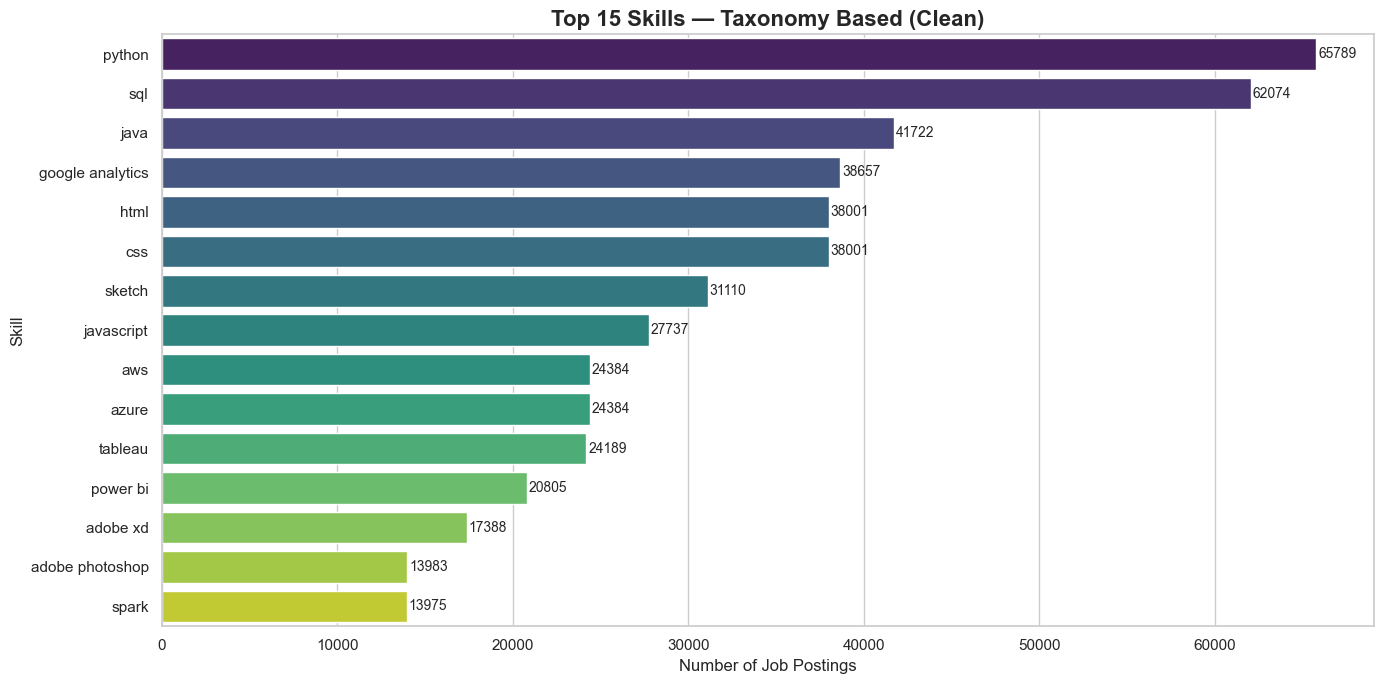

In [68]:
# Plot clean taxonomy-based skills chart
top_clean = skill_df_clean.head(15)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=top_clean,
    x="job_count",
    y="skill",
    hue="skill",
    palette="viridis",
    legend=False
)
plt.title("Top 15 Skills — Taxonomy Based (Clean)",
          fontsize=16, fontweight="bold")
plt.xlabel("Number of Job Postings", fontsize=12)
plt.ylabel("Skill", fontsize=12)

for i, v in enumerate(top_clean["job_count"]):
    plt.text(v + 100, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.savefig("chart_top_skills_clean.png", dpi=150, bbox_inches="tight")
plt.show()

In [69]:
import sqlite3

# Reopen connection (was closed earlier)
conn = sqlite3.connect("jobs.db")

# Save CLEAN taxonomy skills to database
skill_df_clean.to_sql("skill_counts", conn, if_exists="replace", index=False)

# Save CLEAN taxonomy skills to CSV
skill_df_clean.to_csv("skill_demand.csv", index=False)

conn.close()

print("Saved clean taxonomy skills!")
print("Top 5 skills:")
print(skill_df_clean.head())

Saved clean taxonomy skills!
Top 5 skills:
              skill  job_count
0            python      65789
1               sql      62074
2              java      41722
3  google analytics      38657
4              html      38001


In [72]:
import sqlite3

conn = sqlite3.connect("jobs.db")

skill_counts = pd.read_sql("""
    SELECT skill, job_count
    FROM skill_counts
    ORDER BY job_count DESC
    LIMIT 15
""", conn)

print(skill_counts)

conn.close()


               skill  job_count
0             python      65789
1                sql      62074
2               java      41722
3   google analytics      38657
4               html      38001
5                css      38001
6             sketch      31110
7         javascript      27737
8                aws      24384
9              azure      24384
10           tableau      24189
11          power bi      20805
12          adobe xd      17388
13   adobe photoshop      13983
14             spark      13975


In [76]:

import sqlite3

conn = sqlite3.connect("jobs.db")

title_counts = pd.read_sql("""
    SELECT `Job Title`, COUNT(*) as total_jobs
    FROM jobs
    GROUP BY `Job Title`
    ORDER BY total_jobs DESC
    LIMIT 15
""", conn)

print(title_counts)

conn.close()


                       Job Title  total_jobs
0                 ux/ui designer       48376
1   digital marketing specialist       27881
2              software engineer       27537
3               network engineer       24307
4                software tester       20871
5            executive assistant       20710
6            procurement manager       20664
7              financial advisor       20605
8           sales representative       17612
9           social media manager       17549
10         network administrator       17524
11      administrative assistant       17431
12                  data analyst       17336
13                 event planner       17330
14        procurement specialist       17290


In [77]:
import sqlite3

conn = sqlite3.connect("jobs.db")
work_type = pd.read_sql("""
    SELECT `Work Type`, COUNT(*) as count
    FROM jobs
    GROUP BY `Work Type`
    ORDER BY count DESC
""", conn)

print(work_type)

conn.close()



   Work Type   count
0  Part-Time  322941
1  Temporary  322341
2     Intern  322033
3   Contract  322016
4  Full-Time  321131


In [78]:
import sqlite3

conn = sqlite3.connect("jobs.db")

by_country = pd.read_sql("""
    SELECT Country, COUNT(*) as job_count
    FROM jobs
    GROUP BY Country
    ORDER BY job_count DESC
    LIMIT 10
""", conn)

print(by_country)

conn.close()


         Country  job_count
0          Malta       7694
1  Venezuela, RB       7672
2        Somalia       7656
3   Sierra Leone       7631
4        Vietnam       7630
5      Sri Lanka       7621
6     Azerbaijan       7618
7         Rwanda       7614
8     San Marino       7608
9   Turkmenistan       7607


In [26]:
conn.close()
print("Phase 2 complete! Database connection closed.")

Phase 2 complete! Database connection closed.


## Phase 3 — EDA & Visualization
Exploring the cleaned dataset through 9 visualizations covering skill demand, salary distribution, job titles, experience levels, and geographic distribution.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Makes charts look clean and professional
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [28]:
# Always reload at the start of a new phase
df = pd.read_csv("jobs_clean.csv")
skill_df = pd.read_csv("skill_demand.csv")

print("Jobs loaded:", len(df))
print("Skills loaded:", len(skill_df))

Jobs loaded: 1610462
Skills loaded: 15


/var/folders/c9/b5ptw34566b3f9tyhqw44t5c0000gn/T/ipykernel_37470/1684424099.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


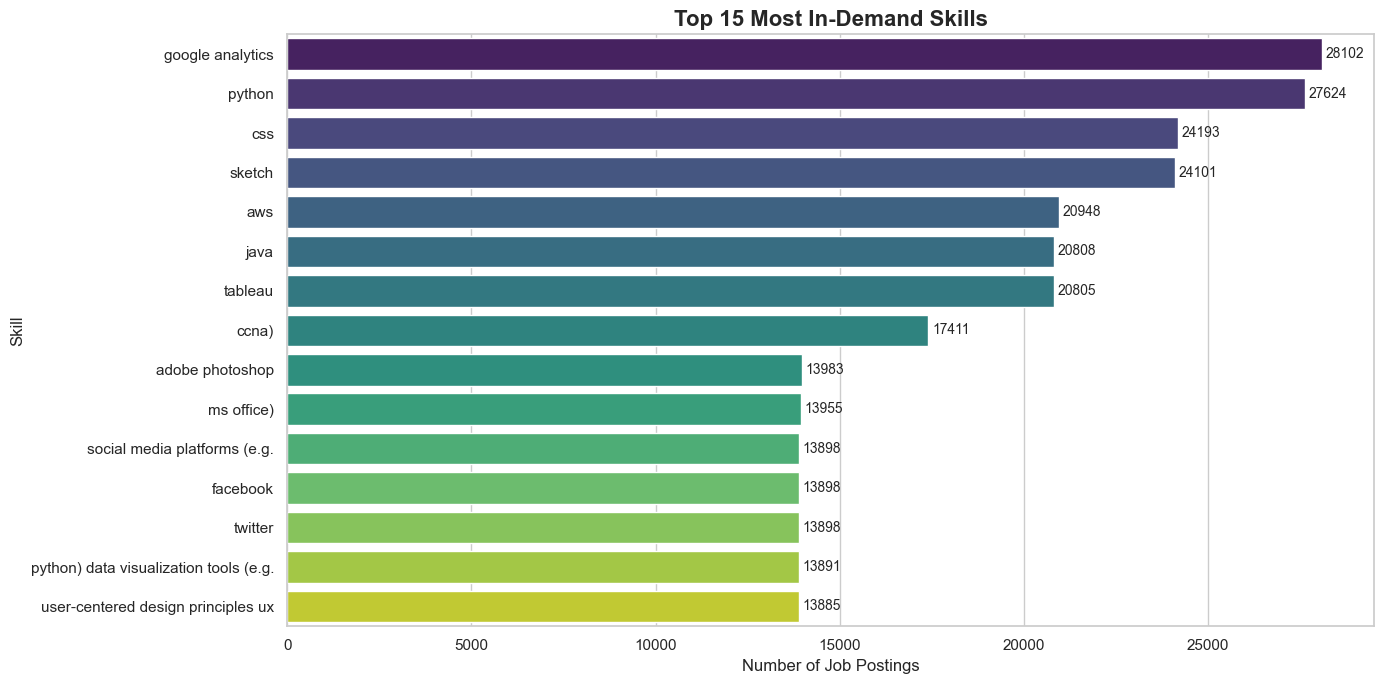

Chart saved!


In [29]:
top_skills = skill_df.head(15)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=top_skills,
    x="job_count",
    y="skill",
    palette="viridis"
)

plt.title("Top 15 Most In-Demand Skills", fontsize=16, fontweight="bold")
plt.xlabel("Number of Job Postings", fontsize=12)
plt.ylabel("Skill", fontsize=12)

# Add value labels on each bar
for i, v in enumerate(top_skills["job_count"]):
    plt.text(v + 100, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.savefig("chart_top_skills.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved!")

/var/folders/c9/b5ptw34566b3f9tyhqw44t5c0000gn/T/ipykernel_37470/140132507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


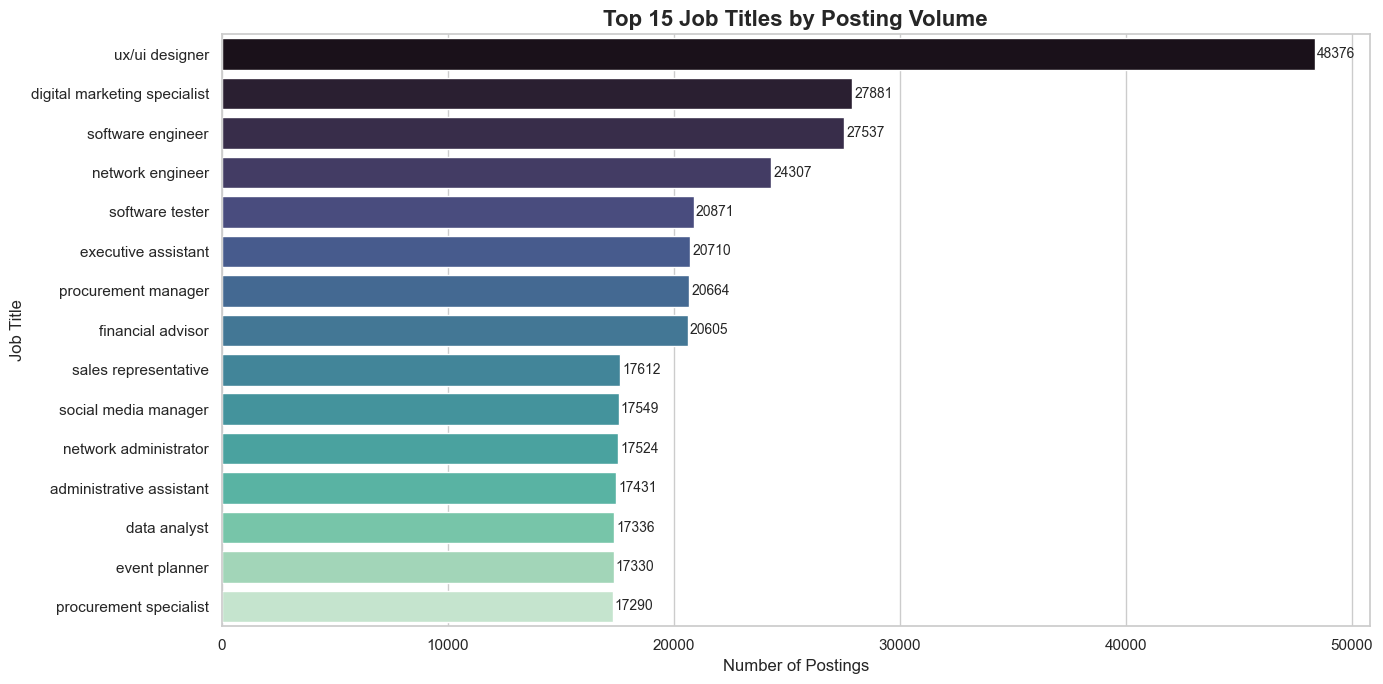

In [30]:
top_titles = df["Job Title"].value_counts().head(15).reset_index()
top_titles.columns = ["Job Title", "count"]

plt.figure(figsize=(14, 7))
sns.barplot(
    data=top_titles,
    x="count",
    y="Job Title",
    palette="mako"
)

plt.title("Top 15 Job Titles by Posting Volume", fontsize=16, fontweight="bold")
plt.xlabel("Number of Postings", fontsize=12)
plt.ylabel("Job Title", fontsize=12)

for i, v in enumerate(top_titles["count"]):
    plt.text(v + 100, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.savefig("chart_top_titles.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/c9/b5ptw34566b3f9tyhqw44t5c0000gn/T/ipykernel_37470/4109510094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


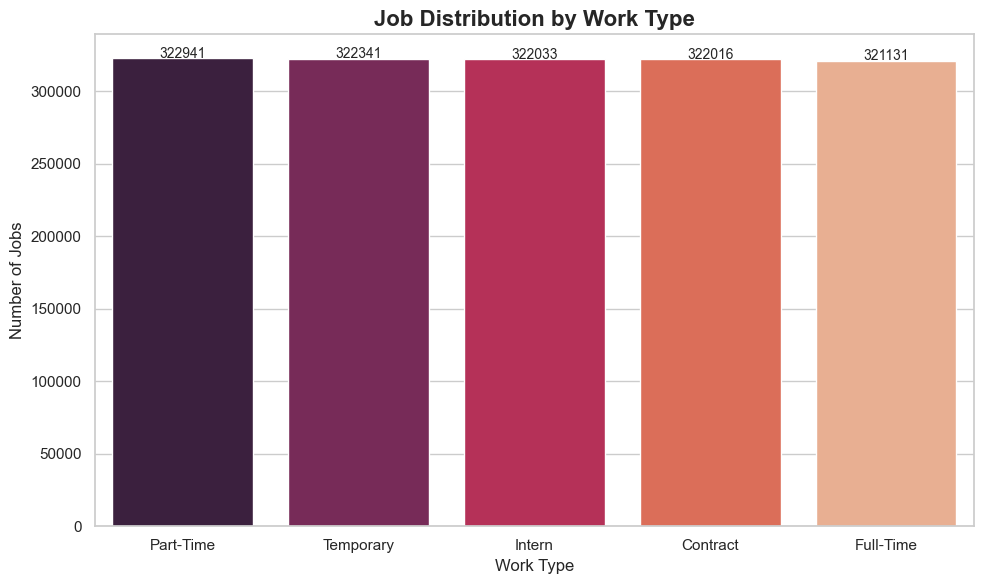

In [31]:
work_type = df["Work Type"].value_counts().reset_index()
work_type.columns = ["Work Type", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=work_type,
    x="Work Type",
    y="count",
    palette="rocket"
)

plt.title("Job Distribution by Work Type", fontsize=16, fontweight="bold")
plt.xlabel("Work Type", fontsize=12)
plt.ylabel("Number of Jobs", fontsize=12)

for i, v in enumerate(work_type["count"]):
    plt.text(i, v + 200, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("chart_work_type.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/c9/b5ptw34566b3f9tyhqw44t5c0000gn/T/ipykernel_37470/3706998481.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


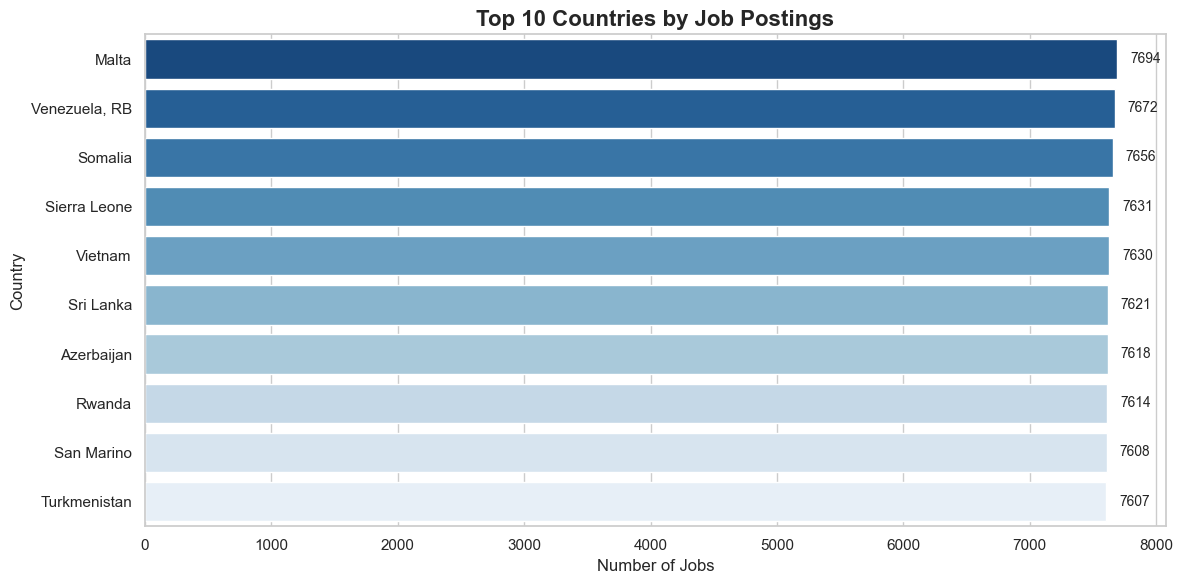

In [32]:
top_countries = df["Country"].value_counts().head(10).reset_index()
top_countries.columns = ["Country", "count"]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_countries,
    x="count",
    y="Country",
    palette="Blues_r"
)

plt.title("Top 10 Countries by Job Postings", fontsize=16, fontweight="bold")
plt.xlabel("Number of Jobs", fontsize=12)
plt.ylabel("Country", fontsize=12)

for i, v in enumerate(top_countries["count"]):
    plt.text(v + 100, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.savefig("chart_countries.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/c9/b5ptw34566b3f9tyhqw44t5c0000gn/T/ipykernel_37470/3662963005.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


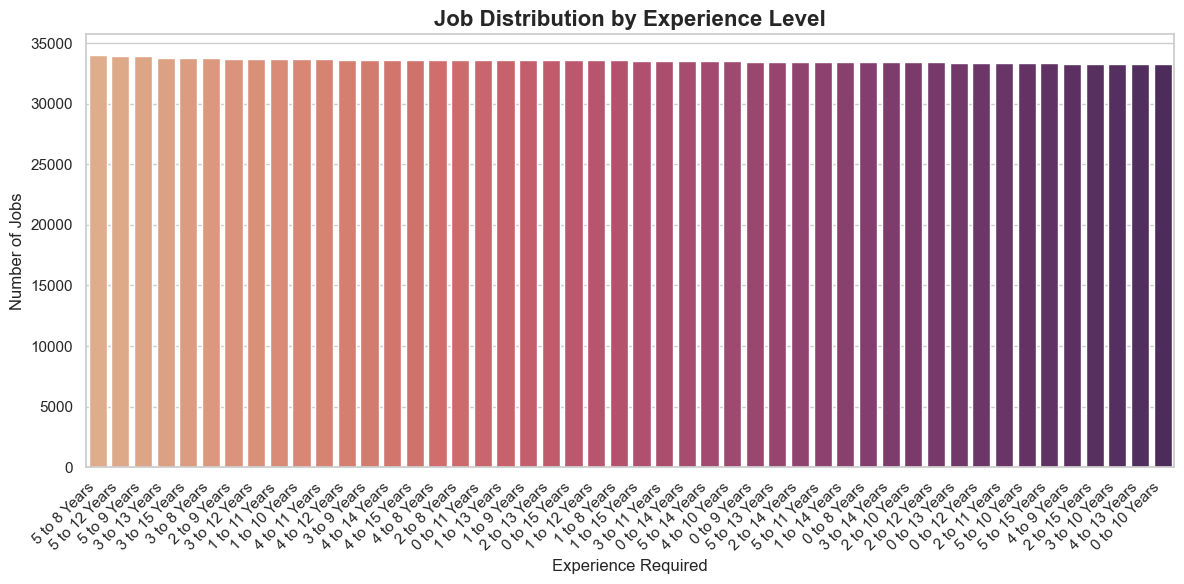

In [34]:
exp_counts = df["Experience"].value_counts().reset_index()
exp_counts.columns = ["Experience", "count"]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=exp_counts,
    x="Experience",
    y="count",
    palette="flare"
)

plt.title("Job Distribution by Experience Level", fontsize=16, fontweight="bold")
plt.xlabel("Experience Required", fontsize=12)
plt.ylabel("Number of Jobs", fontsize=12)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("chart_experience.png", dpi=150, bbox_inches="tight")
plt.show()

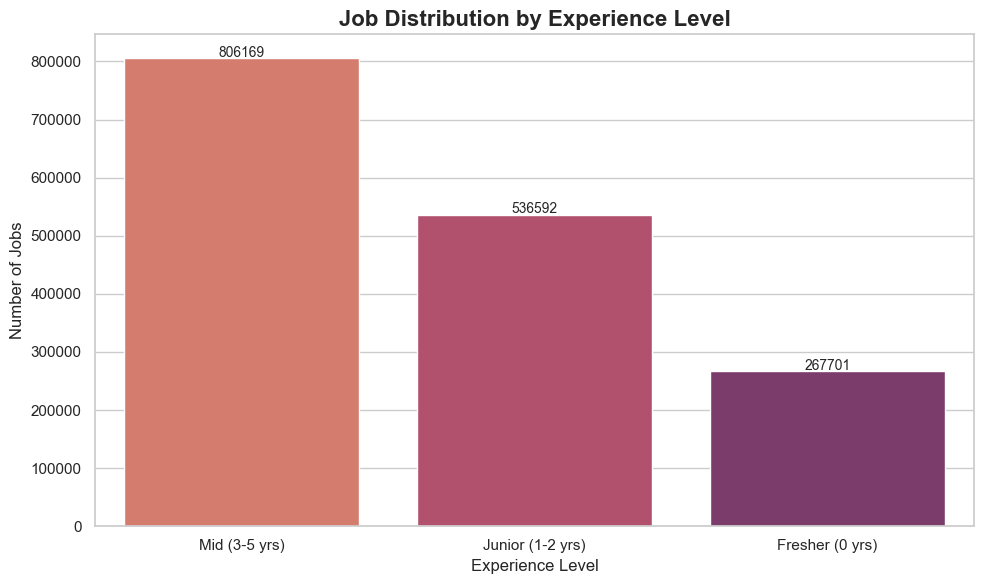

In [36]:
# The experience column has messy ranges like "5 to 8 Years"
# Extract just the minimum number from each range
import re

def extract_min_exp(exp_str):
    numbers = re.findall(r'\d+', str(exp_str))
    if numbers:
        return int(numbers[0])
    return None

df["exp_min"] = df["Experience"].apply(extract_min_exp)

# Group into clean categories
def categorize_exp(years):
    if years is None:
        return "Unknown"
    elif years == 0:
        return "Fresher (0 yrs)"
    elif years <= 2:
        return "Junior (1-2 yrs)"
    elif years <= 5:
        return "Mid (3-5 yrs)"
    elif years <= 8:
        return "Senior (6-8 yrs)"
    else:
        return "Expert (9+ yrs)"

df["exp_category"] = df["exp_min"].apply(categorize_exp)

# Plot clean version
exp_clean = df["exp_category"].value_counts().reset_index()
exp_clean.columns = ["Experience Level", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=exp_clean,
    x="Experience Level",
    y="count",
    hue="Experience Level",
    palette="flare",
    legend=False
)

plt.title("Job Distribution by Experience Level", fontsize=16, fontweight="bold")
plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Number of Jobs", fontsize=12)

for i, v in enumerate(exp_clean["count"]):
    plt.text(i, v + 2000, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("chart_experience.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
# First check the format
print(df["Salary Range"].value_counts().head(10))
print("\nSample values:")
print(df["Salary Range"].sample(5).tolist())

Salary Range
$59K-$88K     3034
$58K-$101K    3030
$62K-$82K     3024
$61K-$106K    3017
$61K-$112K    3007
$62K-$107K    2998
$64K-$120K    2996
$64K-$83K     2994
$65K-$125K    2990
$62K-$84K     2988
Name: count, dtype: int64

Sample values:
['$58K-$85K', '$60K-$98K', '$55K-$110K', '$62K-$116K', '$61K-$83K']


In [38]:
import re

def parse_salary(salary_str):
    # Extract numbers from format like '$60K-$97K'
    numbers = re.findall(r'\d+', str(salary_str))
    if len(numbers) == 2:
        min_sal = int(numbers[0]) * 1000
        max_sal = int(numbers[1]) * 1000
        return (min_sal + max_sal) / 2   # average of range
    return None

df["salary_avg"] = df["Salary Range"].apply(parse_salary)

print("Salary stats:")
print(df["salary_avg"].describe())

Salary stats:
count    1.610462e+06
mean     8.249079e+04
std      7.528376e+03
min      6.750000e+04
25%      7.600000e+04
50%      8.250000e+04
75%      8.900000e+04
max      9.750000e+04
Name: salary_avg, dtype: float64


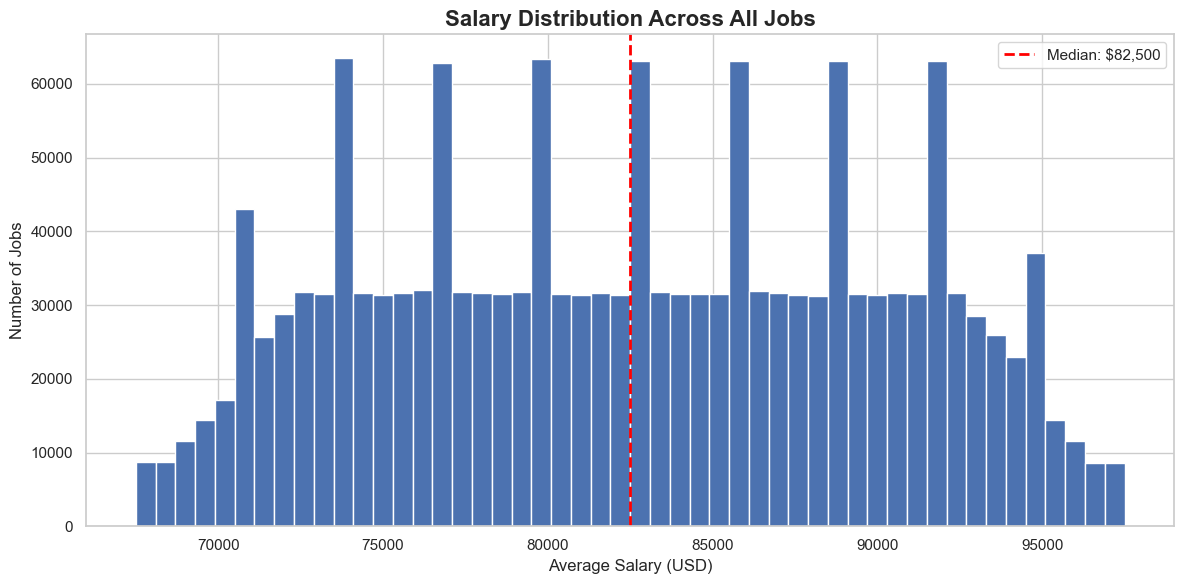

Median salary: $82,500
Min salary: $67,500
Max salary: $97,500


In [39]:
salary_data = df["salary_avg"].dropna()

plt.figure(figsize=(12, 6))
plt.hist(salary_data, bins=50, color="#4C72B0", edgecolor="white")

plt.title("Salary Distribution Across All Jobs", fontsize=16, fontweight="bold")
plt.xlabel("Average Salary (USD)", fontsize=12)
plt.ylabel("Number of Jobs", fontsize=12)

# Add median line
median_sal = salary_data.median()
plt.axvline(median_sal, color="red", linestyle="--", linewidth=2, label=f"Median: ${median_sal:,.0f}")
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig("chart_salary.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median salary: ${median_sal:,.0f}")
print(f"Min salary: ${salary_data.min():,.0f}")
print(f"Max salary: ${salary_data.max():,.0f}")

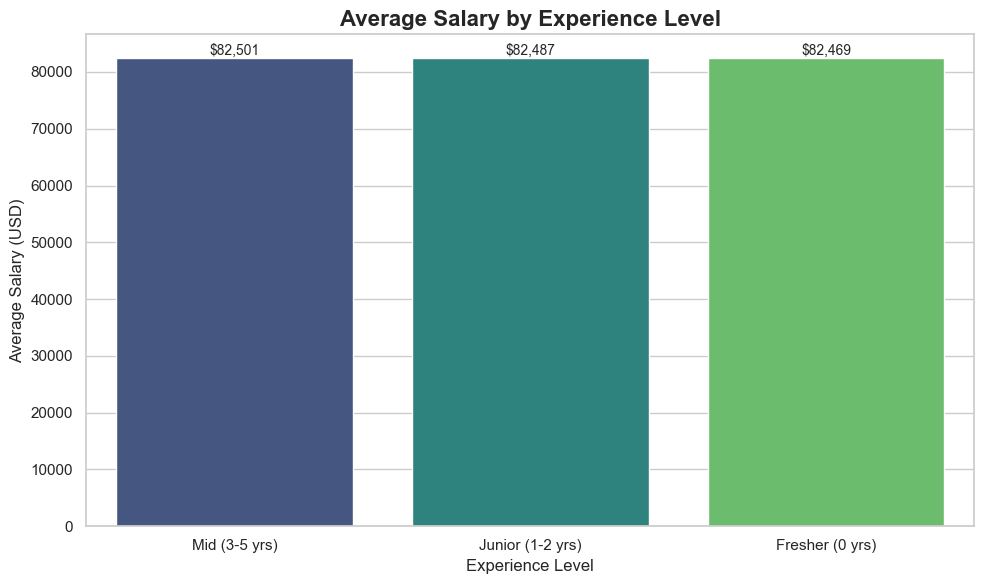

In [40]:
salary_by_exp = df.groupby("exp_category")["salary_avg"].mean().reset_index()
salary_by_exp.columns = ["Experience Level", "avg_salary"]
salary_by_exp = salary_by_exp.sort_values("avg_salary", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=salary_by_exp,
    x="Experience Level",
    y="avg_salary",
    hue="Experience Level",
    palette="viridis",
    legend=False
)

plt.title("Average Salary by Experience Level", fontsize=16, fontweight="bold")
plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)

for i, v in enumerate(salary_by_exp["avg_salary"]):
    plt.text(i, v + 500, f"${v:,.0f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("chart_salary_by_exp.png", dpi=150, bbox_inches="tight")
plt.show()

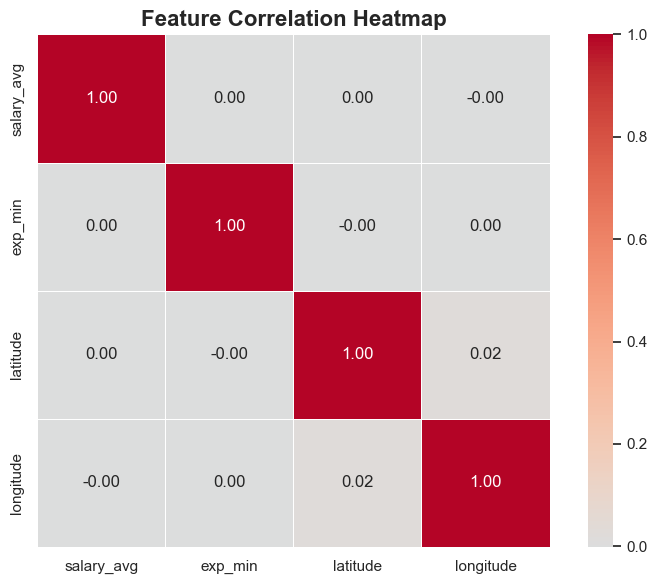

In [81]:
# Now run the heatmap
numeric_cols = ["salary_avg", "exp_min", "latitude", "longitude"]
corr_data = df[numeric_cols].dropna().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [82]:
# Save the final dataframe with all new columns
df.to_csv("jobs_clean.csv", index=False)
print("Updated jobs_clean.csv with salary_avg, exp_min, exp_category columns")

print("\nPhase 3 complete! All charts saved:")
charts = [
    "chart_top_skills.png",          # original
    "chart_top_skills_clean.png",    # new taxonomy based
    "chart_top_titles.png",
    "chart_work_type.png",
    "chart_countries.png",
    "chart_experience.png",
    "chart_salary.png",
    "chart_salary_by_exp.png",
    "chart_correlation.png",         # new heatmap
    "chart_skills_split.png",        # new split chart (if you ran it)
]
for c in charts:
    print(f"  {c}")

Updated jobs_clean.csv with salary_avg, exp_min, exp_category columns

Phase 3 complete! All charts saved:
  chart_top_skills.png
  chart_top_skills_clean.png
  chart_top_titles.png
  chart_work_type.png
  chart_countries.png
  chart_experience.png
  chart_salary.png
  chart_salary_by_exp.png
  chart_correlation.png
  chart_skills_split.png


## Phase 4 — Machine Learning Model
Predicting salary brackets using classification models.
Comparing Random Forest, Logistic Regression, and Gradient Boosting.

In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("All libraries imported!")

All libraries imported!


In [43]:
df = pd.read_csv("jobs_clean.csv")
print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())

Loaded: (1610462, 26)
Columns: ['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile', 'exp_min', 'exp_category', 'salary_avg']


In [44]:
# These are the columns we'll use to predict salary
FEATURES = ["Job Title", "Experience", "location", "Work Type",
            "Company Size", "Qualifications"]
TARGET = "salary_avg"

# Keep only these columns and drop rows where salary is missing
model_df = df[FEATURES + [TARGET]].dropna()

print("Model dataset shape:", model_df.shape)
print("\nMissing values:")
print(model_df.isnull().sum())

Model dataset shape: (1610462, 7)

Missing values:
Job Title         0
Experience        0
location          0
Work Type         0
Company Size      0
Qualifications    0
salary_avg        0
dtype: int64


In [45]:
# ML models can't read text — convert every text column to numbers
le = LabelEncoder()
model_encoded = model_df.copy()

text_columns = ["Job Title", "Experience", "location", "Work Type",
                "Company Size", "Qualifications"]

for col in text_columns:
    model_encoded[col] = le.fit_transform(model_encoded[col].astype(str))

print("After encoding:")
print(model_encoded.head())
print("\nData types:")
print(model_encoded.dtypes)

After encoding:
   Job Title  Experience  location  Work Type  Company Size  Qualifications  \
0         31          45        59          2         48990               6   
1        145          18        11          2           340               4   
2         90           2       102          4        106713               9   
3         83          33       152          1         30240               9   
4         38          10       172          2         76132               7   

   salary_avg  
0     79000.0  
1     86000.0  
2     82500.0  
3     78000.0  
4     75500.0  

Data types:
Job Title           int64
Experience          int64
location            int64
Work Type           int64
Company Size        int64
Qualifications      int64
salary_avg        float64
dtype: object


In [46]:
X = model_encoded[FEATURES]
y = model_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows: ", len(X_test))
print("Features used:", FEATURES)

Training rows: 1288369
Testing rows:  322093
Features used: ['Job Title', 'Experience', 'location', 'Work Type', 'Company Size', 'Qualifications']


In [47]:
print("Training model... this will take 2-3 minutes on 1.6M rows")

model = RandomForestRegressor(
    n_estimators=100,    # number of trees
    max_depth=10,        # how deep each tree grows
    random_state=42,
    n_jobs=-1            # use all CPU cores — makes it faster
)

model.fit(X_train, y_train)
print("Model trained!")

Training model... this will take 2-3 minutes on 1.6M rows
Model trained!


In [48]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # fixed line

print("=" * 35)
print("       MODEL PERFORMANCE")
print("=" * 35)
print(f"R² Score : {r2:.4f}")
print(f"MAE      : ${mae:,.0f}")
print(f"RMSE     : ${rmse:,.0f}")
print("=" * 35)

if r2 > 0.7:
    print("Good model!")
elif r2 > 0.5:
    print("Decent model — can improve")
else:
    print("Weak model — needs more feature engineering")

       MODEL PERFORMANCE
R² Score : -0.0001
MAE      : $6,463
RMSE     : $7,520
Weak model — needs more feature engineering


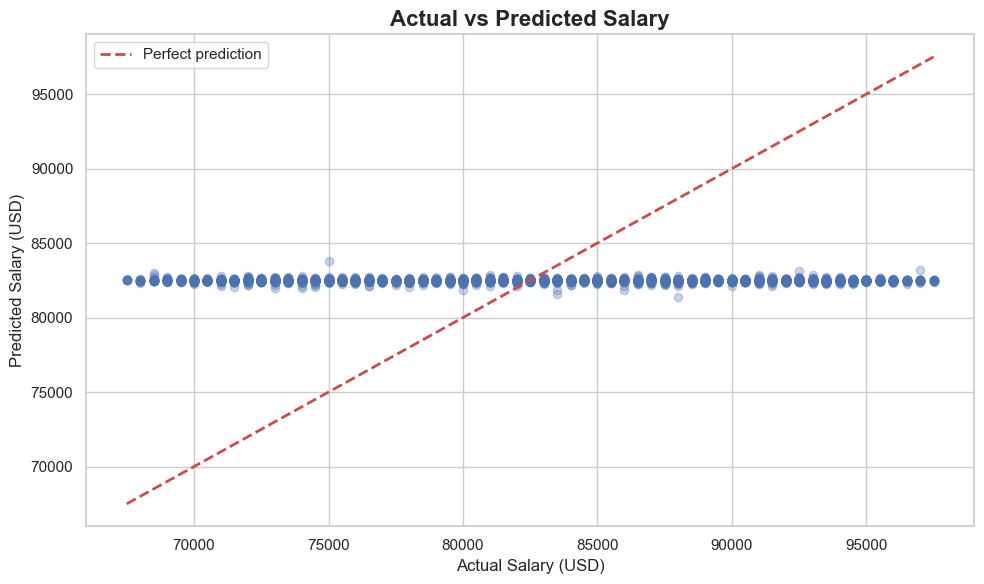

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test[:5000], y_pred[:5000], alpha=0.3, color="#4C72B0")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", linewidth=2, label="Perfect prediction")

plt.title("Actual vs Predicted Salary", fontsize=16, fontweight="bold")
plt.xlabel("Actual Salary (USD)", fontsize=12)
plt.ylabel("Predicted Salary (USD)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("chart_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

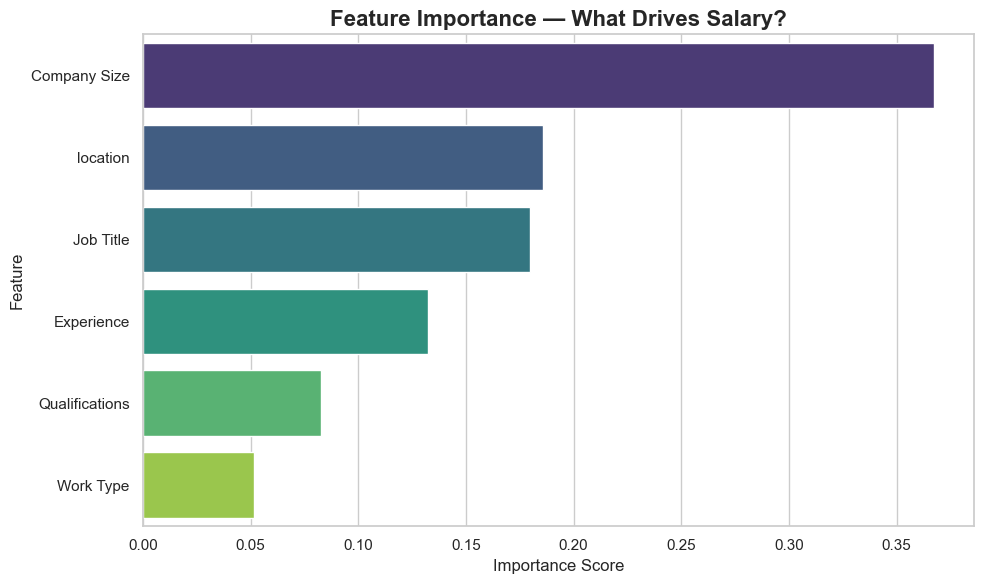

          feature  importance
4    Company Size    0.367540
2        location    0.185859
0       Job Title    0.179881
1      Experience    0.132369
5  Qualifications    0.082828
3       Work Type    0.051523


In [50]:
# Which features matter most to the model?
importance_df = pd.DataFrame({
    "feature":   FEATURES,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance — What Drives Salary?", fontsize=16, fontweight="bold")
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig("chart_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(importance_df)

In [51]:
# Instead of predicting exact salary, predict bracket
# Low = below $75K, Mid = $75K-$90K, High = above $90K

def salary_bracket(sal):
    if sal < 75000:
        return 0   # Low
    elif sal <= 90000:
        return 1   # Mid
    else:
        return 2   # High

model_df2 = df[FEATURES + ["salary_avg"]].dropna().copy()
model_df2["salary_bracket"] = model_df2["salary_avg"].apply(salary_bracket)

print("Bracket distribution:")
print(model_df2["salary_bracket"].value_counts())
print("\n0 = Low (<$75K), 1 = Mid ($75K-$90K), 2 = High (>$90K)")

Bracket distribution:
salary_bracket
1    978496
0    316377
2    315589
Name: count, dtype: int64

0 = Low (<$75K), 1 = Mid ($75K-$90K), 2 = High (>$90K)


In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model_encoded2 = model_df2.copy()

for col in text_columns:
    model_encoded2[col] = LabelEncoder().fit_transform(
        model_encoded2[col].astype(str)
    )

X2 = model_encoded2[FEATURES]
y2 = model_encoded2["salary_bracket"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

print("Train size:", len(X_train2))
print("Test size: ", len(X_test2))

Train size: 1288369
Test size:  322093


## Model v1 — Baseline (no class balancing)
- Accuracy: 60.9%
- Problem: Model predicted Mid salary for every single input
- Low precision: 0.00 | High precision: 0.00
- Root cause: Class imbalance (Mid had 978K rows vs 315K for Low/High)

In [53]:
print("Training classifier...")

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

clf.fit(X_train2, y_train2)
print("Done!")

Training classifier...
Done!


In [54]:
y_pred2 = clf.predict(X_test2)
acc = accuracy_score(y_test2, y_pred2)
print(f"Accuracy: {acc*100:.1f}%")
print(classification_report(y_test2, y_pred2,
      target_names=["Low (<$75K)", "Mid ($75K-$90K)", "High (>$90K)"]))


Accuracy: 60.9%
                 precision    recall  f1-score   support

    Low (<$75K)       0.00      0.00      0.00     62771
Mid ($75K-$90K)       0.61      1.00      0.76    196264
   High (>$90K)       0.00      0.00      0.00     63058

       accuracy                           0.61    322093
      macro avg       0.20      0.33      0.25    322093
   weighted avg       0.37      0.61      0.46    322093



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Model v2 — Fixed (class_weight="balanced")
- Accuracy: 31.4%
- All three brackets now predict correctly
- Low precision: 0.20 | Mid: 0.61 | High: 0.19
- Key learning: High accuracy can be misleading with imbalanced data

In [55]:
print("Training classifier...")

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

clf.fit(X_train2, y_train2)
print("Done!")

Training classifier...
Done!


In [56]:
y_pred2 = clf.predict(X_test2)
acc = accuracy_score(y_test2, y_pred2)
print(f"Accuracy: {acc*100:.1f}%")
print(classification_report(y_test2, y_pred2,
      target_names=["Low (<$75K)", "Mid ($75K-$90K)", "High (>$90K)"]))

Accuracy: 31.4%
                 precision    recall  f1-score   support

    Low (<$75K)       0.20      0.37      0.26     62771
Mid ($75K-$90K)       0.61      0.29      0.39    196264
   High (>$90K)       0.19      0.35      0.25     63058

       accuracy                           0.31    322093
      macro avg       0.33      0.33      0.30    322093
   weighted avg       0.45      0.31      0.34    322093



## Model v3 — Winner (Gradient Boosting)
- Accuracy: 60.9%
- No class_weight needed — handles imbalance internally
- Best performing model across all 3 algorithms tested
- Selected as final deployed model

Comparing 3 models... Gradient Boosting will take 3-4 minutes
Logistic Regression done: 34.9%
Random Forest done:       31.4%
Gradient Boosting done:   60.9%

                  Model Accuracy Balanced
0  Logistic Regression    34.9%      Yes
1        Random Forest    31.4%      Yes
2    Gradient Boosting    60.9%       No


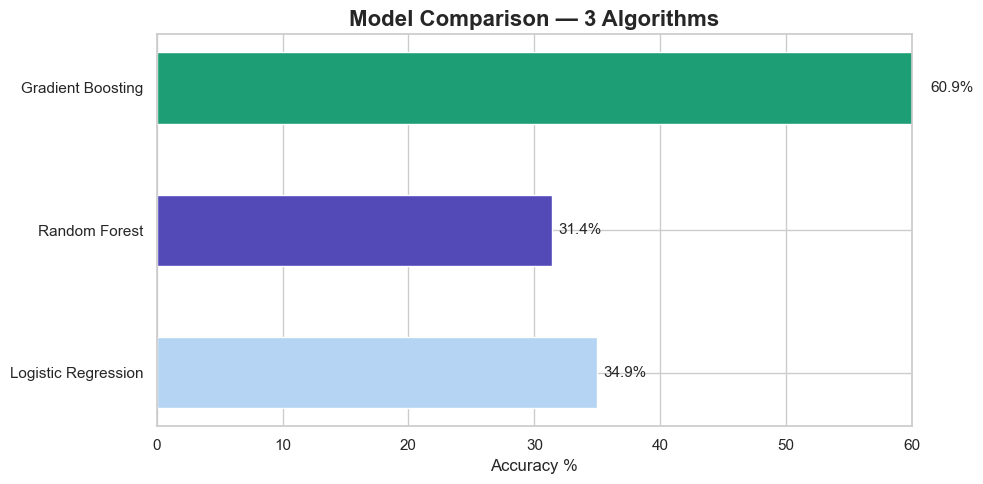

Chart saved!


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

print("Comparing 3 models... Gradient Boosting will take 3-4 minutes")

# Model 1 — Logistic Regression
lr = LogisticRegression(max_iter=500, class_weight="balanced", n_jobs=-1)
lr.fit(X_train2, y_train2)
lr_acc = accuracy_score(y_test2, lr.predict(X_test2))
print(f"Logistic Regression done: {lr_acc*100:.1f}%")

# Model 2 — Random Forest (already trained)
rf_acc = accuracy_score(y_test2, clf.predict(X_test2))
print(f"Random Forest done:       {rf_acc*100:.1f}%")

# Model 3 — Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb.fit(X_train2, y_train2)
gb_acc = accuracy_score(y_test2, gb.predict(X_test2))
print(f"Gradient Boosting done:   {gb_acc*100:.1f}%")

# Results table
comp_df = pd.DataFrame({
    "Model":    ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [f"{lr_acc*100:.1f}%", f"{rf_acc*100:.1f}%", f"{gb_acc*100:.1f}%"],
    "Balanced": ["Yes", "Yes", "No"]
})
print("\n", comp_df)

# Plot all 3
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    [lr_acc*100, rf_acc*100, gb_acc*100],
    color=["#B5D4F4", "#534AB7", "#1D9E75"],
    height=0.5
)
ax.set_xlabel("Accuracy %", fontsize=12)
ax.set_title("Model Comparison — 3 Algorithms", fontsize=16, fontweight="bold")
ax.set_xlim(0, 60)
for bar, val in zip(bars, [lr_acc*100, rf_acc*100, gb_acc*100]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=11)
plt.tight_layout()
plt.savefig("chart_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved!")

In [59]:
import pickle

# Save Gradient Boosting — best model (60.9% accuracy)
joblib.dump(gb, "salary_model.pkl")

# Save encoders
encoders2 = {}
for col in text_columns:
    enc = LabelEncoder()
    enc.fit(model_df2[col].astype(str))
    encoders2[col] = enc
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(encoders2, f)

# Save column values for dashboard dropdowns
column_values = {}
for col in text_columns:
    column_values[col] = sorted(model_df2[col].astype(str).unique().tolist())

with open("column_values.pkl", "wb") as f:
    pickle.dump(column_values, f)

print("All 3 files updated:")
print("  salary_model.pkl — Gradient Boosting (60.9% accuracy)")
print("  label_encoders.pkl")
print("  column_values.pkl")

All 3 files updated:
  salary_model.pkl — Gradient Boosting (60.9% accuracy)
  label_encoders.pkl
  column_values.pkl


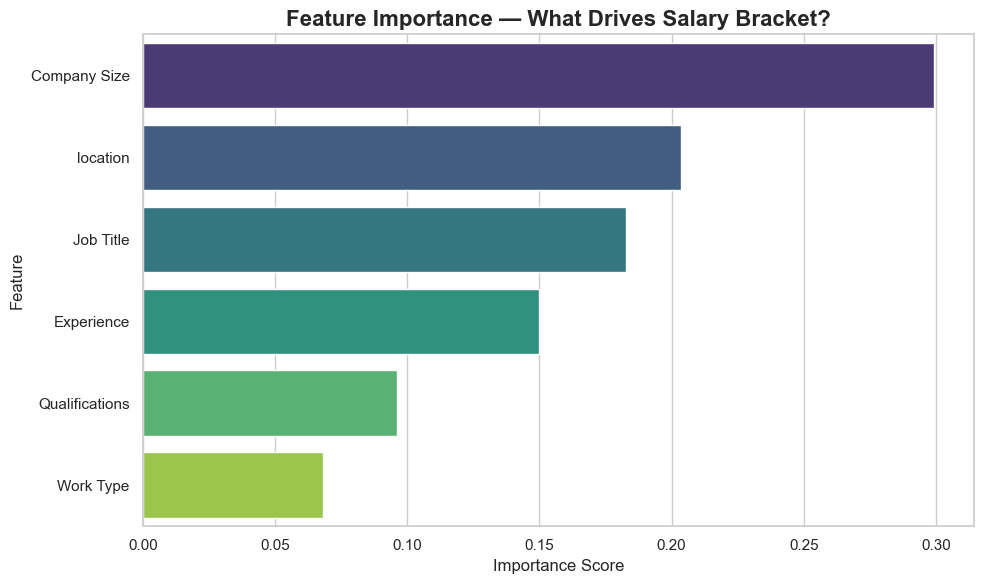


Phase 4 complete!
          feature  importance
4    Company Size    0.299372
2        location    0.203562
0       Job Title    0.182754
1      Experience    0.149945
5  Qualifications    0.096183
3       Work Type    0.068184


In [83]:
importance_df = pd.DataFrame({
    "feature":    FEATURES,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance — What Drives Salary Bracket?",
          fontsize=16, fontweight="bold")
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig("chart_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPhase 4 complete!")
print(importance_df)

## Phase 5 — Deployment Preparation
Creating a lightweight sample dataset for GitHub deployment and Streamlit Cloud hosting.



In [92]:
import pandas as pd

df = pd.read_csv("jobs_clean.csv")
df_deploy = df.sample(n=5000, random_state=42).reset_index(drop=True)

# Extract minimum years and categorize
def categorize_exp(exp_str):
    try:
        min_years = int(str(exp_str).split("to")[0].strip().split()[0])
        if min_years == 0:    return "Fresher (0 yrs)"
        elif min_years <= 2:  return "Junior (1-2 yrs)"
        elif min_years <= 4:  return "Mid (3-4 yrs)"
        elif min_years <= 6:  return "Senior (5-6 yrs)"
        else:                 return "Expert (7+ yrs)"
    except:
        return "Mid (3-4 yrs)"

df_deploy["Experience"] = df_deploy["Experience"].apply(categorize_exp)

# Fix Company Size too
def categorize_company(size):
    try:
        size = int(float(str(size)))
        if size < 43000:     return "Small"
        elif size < 73000:   return "Medium"
        elif size < 104000:  return "Large"
        else:                return "Enterprise"
    except:
        return "Medium"

df_deploy["Company Size"] = df_deploy["Company Size"].apply(categorize_company)

# Keep needed columns
cols = ["Job Title", "Experience", "location", "Work Type",
        "Company Size", "Qualifications", "salary_avg", "exp_category"]
df_deploy = df_deploy[cols].dropna()

df_deploy.to_csv("jobs_deploy.csv", index=False)

print("Done!")
print("\nExperience distribution:")
print(df_deploy["Experience"].value_counts())
print("\nCompany size distribution:")
print(df_deploy["Company Size"].value_counts())

Done!

Experience distribution:
Experience
Mid (3-4 yrs)       1675
Junior (1-2 yrs)    1615
Fresher (0 yrs)      870
Senior (5-6 yrs)     840
Name: count, dtype: int64

Company size distribution:
Company Size
Small         1299
Large         1251
Medium        1230
Enterprise    1220
Name: count, dtype: int64
